# Phase 2 — HMM Regime Detection
Train a 3-state Gaussian HMM on SPY log returns + volatility.
Label each day as **bull / bear / sideways** and plot the result.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src.data import load_data
from src.regimes import RegimeDetector
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

In [2]:
df = load_data("SPY", start="2011-01-01", end="2026-01-01")
print(df.shape)
df.head()

(3771, 4)


,close,daily_return,log_return,volatility
Date,,,,
2011-01-04,96.874763,-0.000551,-0.000551,NaN
2011-01-05,97.378288,0.005198,0.005184,NaN
2011-01-06,97.187561,-0.001959,-0.001961,NaN
2011-01-07,96.996811,-0.001963,-0.001965,NaN
2011-01-10,96.874763,-0.001258,-0.001259,NaN


In [3]:
detector = RegimeDetector(n_regimes=3, random_state=42)
df["regime"] = detector.fit_predict(df)

# What does each regime look like on average?
print(df.groupby("regime")[["daily_return", "volatility"]].mean().round(4))
print("\nRegime counts:")
print(df["regime"].value_counts())

Model is not converging.  Current: 20145.15530888311 is not greater than 20145.242977888483. Delta is -0.08766900537375477


          daily_return  volatility
regime                            
bear           -0.0000      0.2904
bull            0.0007      0.0878
sideways        0.0007      0.1505

Regime counts:
regime
bull        1776
sideways    1300
bear         676
Name: count, dtype: int64


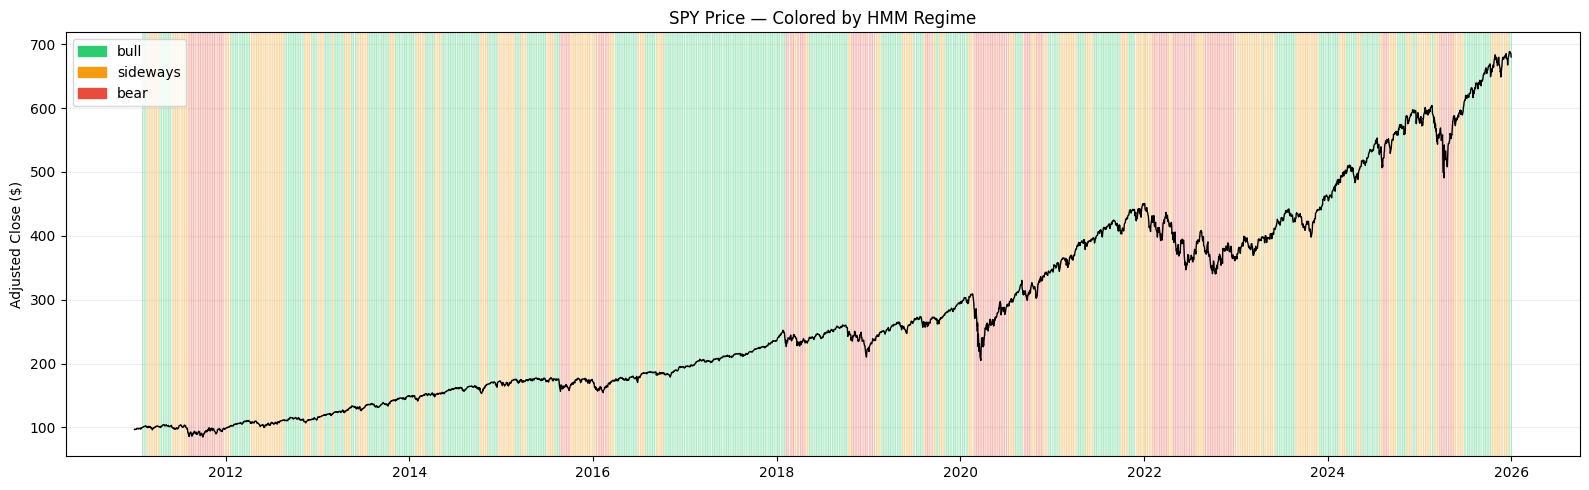

Saved spy_regimes.png


In [11]:
COLORS = {"bull": "#2ecc71", "sideways": "#f39c12", "bear": "#e74c3c"}

fig, ax = plt.subplots(figsize=(16, 5))

# Shade background by regime
for date, regime in df["regime"].items():
    if pd.notna(regime):
        ax.axvline(date, color=COLORS[regime], alpha=0.15, linewidth=0.5)

# Price line on top
ax.plot(df.index, df["close"], color="black", linewidth=1.0, zorder=5)

# Legend
patches = [mpatches.Patch(color=c, label=r) for r, c in COLORS.items()]
ax.legend(handles=patches, loc="upper left")

ax.set_title("SPY Price — Colored by HMM Regime")
ax.set_ylabel("Adjusted Close ($)")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("spy_regimes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved spy_regimes.png")

In [12]:
# Validation: 2008-like crashes and 2020 COVID should be RED (bear)
# 2013-2019 bull run should be mostly GREEN
print("2020 regime counts (COVID crash):")
print(df.loc["2020", "regime"].value_counts())
print("\n2017 regime counts (calm bull):")
print(df.loc["2017", "regime"].value_counts())

2020 regime counts (COVID crash):
regime
bear        138
sideways     60
bull         55
Name: count, dtype: int64

2017 regime counts (calm bull):
regime
bull    251
Name: count, dtype: int64
